# Variant Attribution


**Issues**: 
- `hap_matrix` rows should ideally include all haplotypes, not just unique ones. This makes it easier to match up rows to sample IDs with `np.repeat(ds.samples, 2)`.
- When we want to create `hap_matrix` for an entire gene, we want to take the min/max coordinates of all the regions that correspond to that gene and create a new matrix without redundant variant cols. I suppose this could be done by create new GVL datasets with gene-wise start/end coordinates. But if there's a way to this with our existing site-centered GVL datasets that would be nice.
- Currently, if I pass multiple regions to `get_hap_matrix` is grows the matrix along the haplotype dimension (rows). We want it to only grow via the WT variant dimension (cols).
- We'd like to include identifiers for each WT variant (col). e.g. *HGVS:g.5000A>G* or *HGVS:g.77_80del*


In [2]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
import pandas as pd
import polars as pl
import numpy as np
import glob 
from tqdm import tqdm 
import seaborn as sns
import matplotlib.pyplot as plt
import pooch

import src.utils as utils
import src.vep_analysis as va
import src.clinvar as cv
import src.onekg as og
import src.benchmark.clinvar as bcv
import src.GVL as GVL
import src.analysis.attribution as ab
import src.analysis.matrices as mc


pd.set_option('display.max_columns', None)
import genvarloader as gvl
import awkward as ak


## Determine genes of interest

Grab the region that corresponds to the one centered on each clinical variant.

Sort genes based on how many pathogenic variants that have, as these are less common in ClinvVar.

In [5]:
## Select chrom of interest
chrom="chr17"

bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz").to_pandas()

site_counts = bed.groupby(["chrom","GENE","CLNSIG_simple"])["site"].nunique().sort_values(ascending=False).rename("n_sites").reset_index()
# For each GENE, count the ratio of pathogenic to benign n_sites

# First, filter for pathogenic and benign rows
path_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("path")
benign_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("benign")

# Aggregate n_sites for each gene and class
gene_path = site_counts[path_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_path")
gene_benign = site_counts[benign_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_benign")

# Combine into a single DataFrame
gene_counts = pd.concat([gene_path, gene_benign], axis=1).fillna(0)

# Compute the ratio
gene_counts["path_to_benign_ratio"] = gene_counts["n_path"] / gene_counts["n_benign"].replace(0, np.nan)

# Optionally, sort by ratio descending
gene_counts = gene_counts.sort_values("n_path", ascending=False).reset_index()

print(gene_counts)  


## Get the top gene on the chromosome of interest
gene = gene_counts.loc[gene_counts["chrom"].str.replace("chr", "") == chrom.replace("chr", "")]['GENE'].values[0]
print("GENE:", gene)

Extracting ID columns.
Using default maps.
Simplifying annotations.
     chrom     GENE  n_path  n_benign  path_to_benign_ratio
0       10     PTEN   163.0      21.0              7.761905
1        2    SCN1A   114.0      15.0              7.600000
2        3     MLH1    64.0       9.0              7.111111
3       16     CDH1    64.0      71.0              0.901408
4       17     TP53    56.0      31.0              1.806452
...    ...      ...     ...       ...                   ...
2998    15  RASGRF1     0.0       1.0              0.000000
2999    15    RLBP1     0.0       5.0              0.000000
3000    15     RYR3     0.0       1.0              0.000000
3001    15   SCAPER     0.0       4.0              0.000000
3002     X   ZNF711     0.0       6.0              0.000000

[3003 rows x 5 columns]
GENE: TP53


In [6]:
gene_min_pos = bed.loc[bed["GENE"]==gene]["chromStart"].min() - (2**19//2)
gene_max_pos = bed.loc[bed["GENE"]==gene]["chromEnd"].max() + (2**19//2)

print(gene_min_pos, gene_max_pos, gene_min_pos-gene_max_pos)

7406395 7938729 -532334


## Create haplotype x WT variant matrix: `scikit-allel`

HINT: Install tabix via `htslib` to massively speed up queries:

`conda install bioconda::htslib`

See here for more info on working with `scikit-allel` data structures:  
https://alimanfoo.github.io/2017/06/14/read-vcf.html

In [7]:
import allel
import sys 

vcf_path = os.path.expanduser(f"~/projects/data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz")

# Load the VCF data for the specified region
# The 'fields' argument specifies which fields to extract from the VCF
callset = allel.read_vcf(
    vcf_path,
    region=f"{chrom.replace('chr', '')}:{gene_min_pos}-{gene_max_pos}", 
     log=sys.stdout
) 
genotypes = callset['calldata/GT']  

[read_vcf] 15362 rows in 3.46s; chunk in 3.46s (4441 rows/s)
[read_vcf] all done (4437 rows/s)


Create unique IDs for each WT variant.

In [8]:
vcf_df = allel.vcf_to_dataframe(vcf_path,  
                                 region=f"{chrom.replace('chr', '')}:{gene_min_pos}-{gene_max_pos}")

vcf_df = utils.add_variant_name(vcf_df, 
                       chrom_col="CHROM",
                       start_col="POS",
                       end_col=None,
                       ref_col="REF",
                       alt_col="ALT_1",
                       alias="site")
print(vcf_df.shape)
vcf_df.head()

(15362, 10)


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/allel/io/vcf_read.py:1787: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('', np.nan, inplace=True)


,CHROM,POS,ID,REF,ALT_1,ALT_2,ALT_3,QUAL,FILTER_PASS,site
0,17,7406431,.,G,T,NaN,NaN,NaN,True,chr17:7406431-7406432_G_T
1,17,7406451,.,C,G,NaN,NaN,NaN,True,chr17:7406451-7406452_C_G
2,17,7406455,.,G,A,NaN,NaN,NaN,True,chr17:7406455-7406456_G_A
3,17,7406516,.,T,C,NaN,NaN,NaN,True,chr17:7406516-7406517_T_C
4,17,7406545,.,T,C,NaN,NaN,NaN,True,chr17:7406545-7406546_T_C


In [9]:
gt = allel.GenotypeArray(callset['calldata/GT'])

Xwt = pd.DataFrame(
    gt.to_sparse().T.toarray(),
    columns=vcf_df['site'].values,
    index=np.array([f"{sample}_{i}" for sample in callset['samples'] for i in range(2)])
) 

print(Xwt.shape)
Xwt.iloc[:10,:10]

(5096, 15362)


,chr17:7406431-7406432_G_T,chr17:7406451-7406452_C_G,chr17:7406455-7406456_G_A,chr17:7406516-7406517_T_C,chr17:7406545-7406546_T_C,chr17:7406594-7406595_C_T,chr17:7406599-7406600_G_A,chr17:7406687-7406688_T_C,chr17:7406758-7406759_C_A,chr17:7406764-7406765_G_T
HG00096_0,0,0,0,0,0,0,0,0,0,0
HG00096_1,0,0,0,0,0,0,0,0,0,0
HG00097_0,0,0,0,0,0,0,0,1,0,0
HG00097_1,0,0,0,0,0,0,0,0,0,0
HG00099_0,0,0,0,0,0,0,0,0,0,0
HG00099_1,0,0,0,0,0,0,0,0,0,0
HG00100_0,0,0,0,0,0,0,0,0,0,0
HG00100_1,0,0,0,0,0,0,0,0,0,0
HG00101_0,0,0,0,0,0,0,0,1,0,0
HG00101_1,0,0,0,0,0,0,0,0,0,0


## Create haplotype x WT variant matrix: `genvarloader`

In [85]:
onedrive_dir = os.path.expanduser("~/onedrive/VEP_DNA/1000_Genomes_on_GRCh38/clinvar_utr_snv")
pq_files = glob.glob(os.path.join(onedrive_dir, "*.parquet"))
gvl_files = glob.glob(os.path.join(onedrive_dir, "*.gvl"))

pq_file_chrom = [x for x in pq_files if  chrom in x][0]
gvl_file_chrom = [x for x in gvl_files if chrom in x][0]

IndexError: list index out of range

In [ ]:
ds = gvl.Dataset.open(gvl_file_chrom)   
cohort = "1000_Genomes_on_GRCh38" 
reference = pooch.retrieve(
        url=og.get_ftp_dict()[cohort]['ref'],
        known_hash=None,
        progressbar=True
    )
ds = (
        gvl.Dataset.open(gvl_file_chrom, reference=reference)
        .with_seqs("annotated") 
        .with_len(2**19)
    )  

2025-08-24 20:44:55.200 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-08-24 20:44:57.760 | WARNING  | genvarloader._dataset._impl:open:178 - No reference: dataset only has genotypes but no reference was given. Resulting dataset can only support :code:`.with_seqs('variants')` to return RaggedVariants.
2025-08-24 20:44:57.761 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/onedrive/VEP_DNA/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl
Is subset: False
# of regions: 1026
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None

2025-08-24 20:45:03.046 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-08-24 20:45:06.747 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/onedrive/VEP_DNA/100

In [ ]:
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

bed_chrom = bed.filter(pl.col('chrom').str.replace("chr", "")==chrom.replace("chr", ""))
sites_chrom = cv.bed_to_sites(bed_chrom)
site_ds = gvl.DatasetWithSites(ds, sites_chrom) 

region_to_site = GVL.filter_region_to_site(site_ds.rows)
region_to_site

Extracting ID columns.
Using default maps.
Simplifying annotations.
Sites before filter_region_to_site:  (35710, 99)
Sites after site_filters:  (1026, 100)
Sites after region_idx==site_idx filter:  (1026, 100)


index,region_idx,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,…,CLNDISDB_site,CLNDN_site,CLNHGVS_site,CLNREVSTAT_site,CLNSIG_site,CLNVC_site,CLNVCSO_site,CLNSIGCONF_site,GENEINFO_site,MC_site,ORIGIN_site,RS_site,ONC_site,ONCDN_site,ONCDISDB_site,ONCREVSTAT_site,ONCCONF_site,SCI_site,SCIDN_site,SCIDISDB_site,SCIREVSTAT_site,CLNREVSTAT_score_site,site_site,MONDO_site,MONDO_n_site,OMIM_site,OMIM_n_site,Orphanet_site,Orphanet_n_site,MedGen_site,MedGen_n_site,MeSH_site,MeSH_n_site,CLNSIG_simple_site,CLNSIG_super_simple_site,GENE_site,POS0
u32,u32,cat,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,…,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,str,list[str],u32,list[str],u32,list[str],u32,list[str],u32,list[str],u32,str,str,str,i64
0,0,"""17""",452609,976897,"""chr17:714753-714754_C_T""",2.0,"""C""","""T""","""SO:0001623""","""5_prime_UTR_variant""",0.07503,0.06871,0.03095,378741,"""MedGen:C3661900|MedGen:CN16937…","""not_provided|not_specified""","""NC_000017.11:g.714753C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""VPS53:55275""","""SO:0001623|5_prime_UTR_variant""",1,35915949,null,null,null,null,null,null,null,null,null,2,…,"""MedGen:C3661900|MedGen:CN16937…","""not_provided|not_specified""","""NC_000017.11:g.714753C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""VPS53:55275""","""SO:0001623|5_prime_UTR_variant""",1,35915949,null,null,null,null,null,null,null,null,null,2,"""chr17:714753-714754_C_T""",[],0,[],0,[],0,"[""MedGen:C3661900"", ""MedGen:CN169374""]",2,[],0,"""benign""","""benign""","""VPS53""",714752
5,1,"""17""",452655,976943,"""chr17:714799-714800_G_A""",2.0,"""G""","""A""","""SO:0001623""","""5_prime_UTR_variant""",null,null,0.51298,656467,"""MONDO:MONDO:0014370,MedGen:C40…","""Pontocerebellar_hypoplasia_typ…","""NC_000017.11:g.714799G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""VPS53:55275""","""SO:0001623|5_prime_UTR_variant""",1,2474694,null,null,null,null,null,null,null,null,null,2,…,"""MONDO:MONDO:0014370,MedGen:C40…","""Pontocerebellar_hypoplasia_typ…","""NC_000017.11:g.714799G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""VPS53:55275""","""SO:0001623|5_prime_UTR_variant""",1,2474694,null,null,null,null,null,null,null,null,null,2,"""chr17:714799-714800_G_A""","[""MONDO:MONDO:0014370""]",1,"[""OMIM:615851""]",1,"[""Orphanet:247198""]",1,"[""MedGen:C4014488"", ""MedGen:C3661900""]",2,[],0,"""benign""","""benign""","""VPS53""",714798
10,2,"""17""",538633,1062921,"""chr17:800777-800778_A_G""",2.0,"""A""","""G""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.60184,1263681,"""MedGen:C3661900""","""not_provided""","""NC_000017.11:g.800777A>G""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""NXN:64359""","""SO:0001624|3_prime_UTR_variant""",1,2474695,null,null,null,null,null,null,null,null,null,2,…,"""MedGen:C3661900""","""not_provided""","""NC_000017.11:g.800777A>G""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""NXN:64359""","""SO:0001624|3_prime_UTR_variant""",1,2474695,null,null,null,null,null,null,null,null,null,2,"""chr17:800777-800778_A_G""",[],0,[],0,[],0,"[""MedGen:C3661900""]",1,[],0,"""benign""","""benign""","""NXN""",800776
16,3,"""17""",538658,1062946,"""chr17:800802-800803_T_G""",2.0,"""T""","""G""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.19768,1249423,"""MedGen:C3

Subset the GVL dataset to a regions of interest for a specific gene and compute the binarized haplotype x WT variant matrix.

In [ ]:
roi = region_to_site.filter(pl.col("GENE") == gene)
print(roi.shape)
roi  

GENE: TP53
(87, 100)


index,region_idx,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,…,CLNDISDB_site,CLNDN_site,CLNHGVS_site,CLNREVSTAT_site,CLNSIG_site,CLNVC_site,CLNVCSO_site,CLNSIGCONF_site,GENEINFO_site,MC_site,ORIGIN_site,RS_site,ONC_site,ONCDN_site,ONCDISDB_site,ONCREVSTAT_site,ONCCONF_site,SCI_site,SCIDN_site,SCIDISDB_site,SCIREVSTAT_site,CLNREVSTAT_score_site,site_site,MONDO_site,MONDO_n_site,OMIM_site,OMIM_n_site,Orphanet_site,Orphanet_n_site,MedGen_site,MedGen_n_site,MeSH_site,MeSH_n_site,CLNSIG_simple_site,CLNSIG_super_simple_site,GENE_site,POS0
u32,u32,cat,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,…,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,i64,str,list[str],u32,list[str],u32,list[str],u32,list[str],u32,list[str],u32,str,str,str,i64
7640,184,"""17""",7406395,7930683,"""chr17:7668539-7668540_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.00779,347484,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Hereditary_cancer…","""NC_000017.11:g.7668539G>A""","""criteria_provided,_multiple_su…","""Benign/Likely_benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,114831472,null,null,null,null,null,null,null,null,null,2,…,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Hereditary_cancer…","""NC_000017.11:g.7668539G>A""","""criteria_provided,_multiple_su…","""Benign/Likely_benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,114831472,null,null,null,null,null,null,null,null,null,2,"""chr17:7668539-7668540_G_A""","[""MONDO:MONDO:0015356""]",1,"[""OMIM:151623""]",1,"[""Orphanet:140162"", ""Orphanet:524""]",2,"[""MedGen:C3661900"", ""MedGen:C0027672"", ""MedGen:C1835398""]",3,"[""MeSH:D009386""]",1,"""likely_benign""","""benign""","""TP53""",7668538
7737,185,"""17""",7406639,7930927,"""chr17:7668783-7668784_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.05711,340457,"""Gene:553989,MedGen:C1835398,OM…","""Li-Fraumeni_syndrome_1|not_pro…","""NC_000017.11:g.7668783C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,17884306,null,null,null,null,null,null,null,null,null,2,…,"""Gene:553989,MedGen:C1835398,OM…","""Li-Fraumeni_syndrome_1|not_pro…","""NC_000017.11:g.7668783C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,17884306,null,null,null,null,null,null,null,null,null,2,"""chr17:7668783-7668784_C_T""","[""MONDO:MONDO:0015356""]",1,"[""OMIM:151623""]",1,"[""Orphanet:524"", ""Orphanet:140162""]",2,"[""MedGen:C1835398"", ""MedGen:C3661900"", ""MedGen:C0027672""]",3,"[""MeSH:D009386""]",1,"""benign""","""benign""","""TP53""",7668782
7834,186,"""17""",7406980,7931268,"""chr17:7669124-7669125_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.05112,340463,"""Gene:553989,MedGen:C1835398,OM…","""Li-Fraumeni_syndrome_1|Heredit…","""NC_000017.11:g.7669124C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,4968187,null,null,null,null,null,null,null,null,null,2,…,"""Gene:553989,MedGen:C1835398,OM…","""Li-Fraumeni_syndrome_1|Heredit…","""NC_000017.11:g.7669124C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""",null,"""TP53:7157""","""SO:0001624|3_prime_UTR_variant""",1,4968187,null,null,null,null,nu

In [ ]:
r_idx = ds._idxer._r_idx[[0]]
shape = (1, ds.n_samples, ds.ploidy)
genos = ak.to_packed(ds._seqs.genotypes[r_idx])
v_idxs = genos.data
offsets = genos.offsets

hap_ids, hap_id_offsets, hap_membership, hap_matrix = GVL.get_hap_matrix(v_idxs, offsets)

hap_memberships = hap_membership.reshape(shape)
hap_ids = gvl.Ragged.from_offsets(hap_ids, (len(hap_id_offsets) - 1, None), hap_id_offsets)

print("hap_matrix.shape:", hap_matrix.shape)

100%|██████████| 5096/5096 [00:00<00:00, 47267.29it/s]


Create named df from hap_matrix.

In [ ]:
wt_variant_names = GVL.get_variant_ids(ds, v_idxs)
print(len(wt_variant_names))
flat_index = GVL.get_haplotype_ids(ds, hap_matrix)

Xwt = pd.DataFrame(hap_matrix, 
                   index=flat_index, 
                   columns=wt_variant_names)

# Drop variants without any alt information
# dropped_wt_variants = Xwt.columns.str.endswith(">")
# Xwt = Xwt.loc[:, ~dropped_wt_variants]

In [ ]:
Xwt.sum(axis=0).describe()

count    14924.000000
mean       185.145001
std        698.810927
min          1.000000
25%          1.000000
50%          2.000000
75%         11.000000
max       5095.000000
dtype: float64

In [62]:
ak.all(hap_ids[hap_memberships] == genos)

True

Count the number of variants in which there is no variation.

These are probably cases where almost everyone has the non-REF allele (i.e. the REF is not representative of population-derived data).

In [ ]:
sum(np.unique(hap_matrix[:, i]).size < 2 for i in range(hap_matrix.shape[1]))

8

Count the number of variants per haplotype.

In [ ]:
ds.subset_to(regions=0).n_variants()

array([[[462, 697],
        [641, 664],
        [543, 602],
        ...,
        [636, 594],
        [687, 605],
        [648, 748]]])

In [ ]:
_, cnts = np.unique(hap_membership, return_counts=True)
ax = sns.ecdfplot(cnts)
ax.set_xscale("log")

## Compute linkage disequilibrium map

In [10]:
Xld = np.corrcoef(Xwt, rowvar=False) 
print(Xld.shape) 

(15362, 15362)


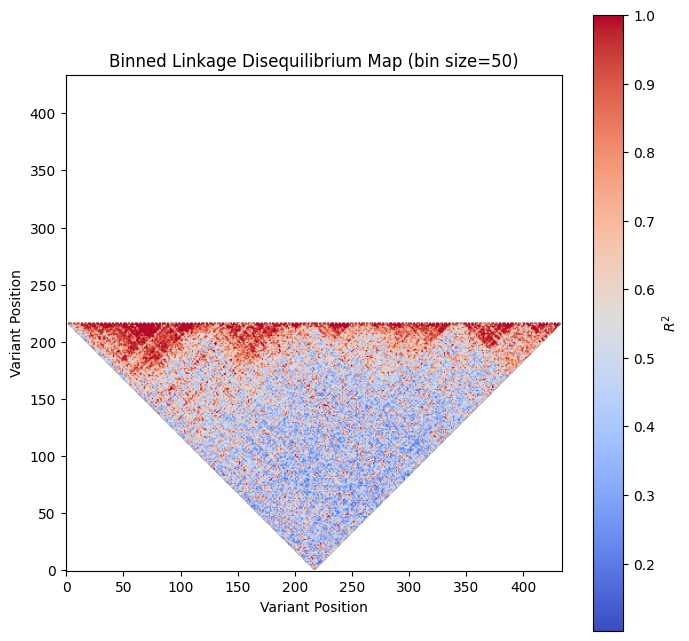

In [11]:
bin_size = 50
n_bins = Xld.shape[0] // bin_size  

# Bin the squared correlation matrix by max within each bin
Xld_binned = mc.bin_matrix(Xld, 
                           bin_size=bin_size, 
                           agg_func=np.nanmax)
 
# Mask everything except the diagonal band (upper triangle, including diagonal)
mask = np.ones_like(Xld_binned, dtype=bool)
for i in range(n_bins):
    for j in range(n_bins):
        if j >= i:
            mask[i, j] = False

# Set masked values to np.nan so they plot as transparent after rotation
Xld_binned_masked = Xld_binned.copy()
Xld_binned_masked[mask] = np.nan

# Rotate the matrix by 45 degrees
from scipy.ndimage import rotate

rotated = rotate(Xld_binned_masked, 45, reshape=True, order=1, mode='constant', cval=np.nan)

# Plot, ensuring nan values are transparent
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    rotated,
    cmap="coolwarm",
    origin="lower", 
    # vmin=-1,
    # vmax=1,
)
# Set nan color to fully transparent
im.set_alpha(np.where(np.isnan(rotated), 0.0, 1.0).astype(np.float32))

ax.set_xlabel("Variant Position")
ax.set_ylabel("Variant Position")
ax.set_title(f"Binned Linkage Disequilibrium Map (bin size={bin_size})")
plt.colorbar(im, ax=ax, label="$R^2$")
plt.show()


## Plot sample metadata

0 samples are missing superpopulation metadata


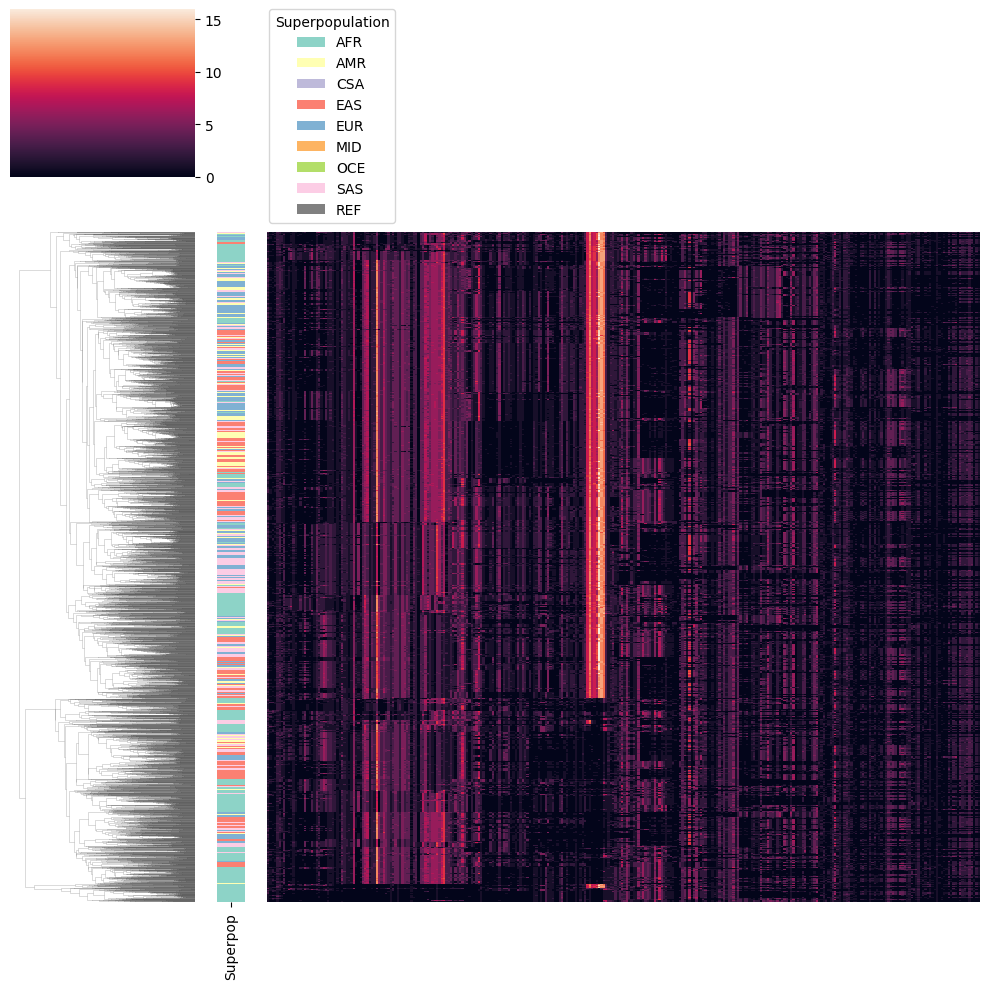

In [12]:
binned_matrix = mc.bin_matrix_col(Xwt, bin_size=50, agg_func=np.nansum)

sample_metadata = og.get_sample_metadata().set_index("sample") 
meta = sample_metadata.copy().loc[[x.split("_")[0] for x in binned_matrix.index]]
# Create the new phased index
meta.index = binned_matrix.index

palette = utils.get_superpop_palette()
meta["Superpop"] = meta["superpopulation"].map(palette)


ax = sns.clustermap(
    binned_matrix,
    xticklabels=False,
    yticklabels=False,
    row_cluster=True,
    col_cluster=False,
    row_colors=meta[["Superpop"]],
    # cbar_kws=dict(use_gridspec=True,location="top",pad=0.01,shrink=0.1)
)
# Reduce dendrogram alpha after creation
for dendro in [ax.ax_row_dendrogram, ax.ax_col_dendrogram]:
    for line in dendro.collections:
        line.set_alpha(0.25)

from matplotlib.patches import Patch

handles = [Patch(facecolor=palette[name]) for name in palette]
plt.legend(handles, palette.keys(), title='Superpopulation', 
               bbox_to_anchor=(1.4, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.show()


### Read in VEP data

In [ ]:
save_dir = os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv")
pq_files = glob.glob(os.path.join(save_dir, "*.parquet")) 

pq_file_chrom = [x for x in pq_files if  chrom in x][0] 

### Polars sucks at scanning remote parquet files
# import polars as pl
# vep_df = pl.scan_parquet(pq_file_chrom).filter(pl.col("slot") == "COVR").collect()

vep_df = pd.read_parquet(pq_file_chrom)
vep_df = vep_df.loc[vep_df["slot"] == "COVR"].dropna("flashzoi")
vep_df["VEP"] = vep_df["flashzoi"]
print(vep_df.shape)
vep_df.head()

(5230548, 14)


,index,site,sample,ploid,slot,evo2_40b_base,evo2_7b_base,evo2_7b,spliceai_mm,spliceai,evo2_40b,flashzoi,dnabert2,VEP
__null_dask_index__,,,,,,,,,,,,,,
0,0,chr17:82443774-82443775_C_T,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,14,chr17:82443774-82443775_C_T,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,chr17:82443774-82443775_C_T,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,42,chr17:82443774-82443775_C_T,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,56,chr17:82443774-82443775_C_T,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
y_vep = vep_df.loc[vep_df["site"].isin(bed.loc[bed["GENE"] == gene]["site"])].pivot_table(
    index=["sample", "ploid"], 
    columns="site", 
    values="VEP"
)
# Flatten the MultiIndex for the rows
y_vep.index = [f"{s}_{p}" for s, p in y_vep.index]
print(y_vep.shape)
y_vep

(5098, 87)


site,chr17:7668539-7668540_G_A,chr17:7668783-7668784_C_T,chr17:7669124-7669125_C_T,chr17:7669200-7669201_G_T,chr17:7669252-7669253_A_G,chr17:7669404-7669405_C_T,chr17:7669603-7669604_A_T,chr17:7669628-7669629_T_G,chr17:7669640-7669641_A_G,chr17:7669641-7669642_T_C,chr17:7669655-7669656_C_A,chr17:7669655-7669656_C_T,chr17:7669656-7669657_G_T,chr17:7669671-7669672_C_G,chr17:7670613-7670614_A_C,chr17:7670616-7670617_G_A,chr17:7670630-7670631_C_G,chr17:7670643-7670644_C_G,chr17:7670649-7670650_G_T,chr17:7670658-7670659_T_A,chr17:7670664-7670665_C_A,chr17:7670669-7670670_G_T,chr17:7670678-7670679_A_G,chr17:7670684-7670685_C_G,chr17:7670684-7670685_C_T,chr17:7670685-7670686_G_A,chr17:7670694-7670695_C_A,chr17:7670694-7670695_C_G,chr17:7670699-7670700_C_A,chr17:7670699-7670700_C_G,chr17:7670699-7670700_C_T,chr17:7670700-7670701_G_A,chr17:7670706-7670707_G_A,chr17:7670709-7670710_C_A,chr17:7670711-7670712_C_T,chr17:7670712-7670713_G_A,chr17:7675136-7675137_G_A,chr17:7675136-7675137_G_T,chr17:7675139-7675140_C_A,chr17:7675139-7675140_C_G,chr17:7675139-7675140_C_T,chr17:7675142-7675143_A_C,chr17:7675143-7675144_C_A,chr17:7675143-7675144_C_T,chr17:7675145-7675146_C_G,chr17:7675148-7675149_G_T,chr17:7675157-7675158_G_A,chr17:7675157-7675158_G_C,chr17:7675160-7675161_G_C,chr17:7675161-7675162_G_A,chr17:7675161-7675162_G_C,chr17:7675161-7675162_G_T,chr17:7675174-7675175_C_T,chr17:7675175-7675176_C_T,chr17:7675182-7675183_G_A,chr17:7675184-7675185_A_G,chr17:7675185-7675186_C_T,chr17:7675189-7675190_G_C,chr17:7675190-7675191_C_T,chr17:7675200-7675201_C_G,chr17:7675206-7675207_G_A,chr17:7675208-7675209_C_A,chr17:7675209-7675210_A_C,chr17:7675209-7675210_A_G,chr17:7675212-7675213_A_T,chr17:7675214-7675215_A_G,chr17:7675216-7675217_C_A,chr17:7675216-7675217_C_G,chr17:7675217-7675218_T_C,chr17:7675220-7675221_T_A,chr17:7675223-7675224_A_G,chr17:7675232-7675233_G_A,chr17:7675232-7675233_G_T,chr17:7675233-7675234_A_G,chr17:7675234-7675235_G_C,chr17:7675237-7675238_C_A,chr17:7675237-7675238_C_T,chr17:7675238-7675239_T_A,chr17:7675238-7675239_T_C,chr17:7676257-7676258_G_A,chr17:7676262-7676263_G_T,chr17:7676264-7676265_C_G,chr17:7676405-7676406_T_C,chr17:7676567-7676568_C_G,chr17:7676567-7676568_C_T,chr17:7676574-7676575_A_T,chr17:7676584-7676585_G_A
HG00096_0,0.604416,0.404797,0.637196,0.705528,0.772902,0.431901,0.710960,0.871095,0.655572,0.490663,1.903873,1.296783,0.714747,3.842743,0.695757,0.540592,0.527767,0.939643,0.653625,0.421821,0.452608,0.662092,0.856164,0.418747,0.561543,0.635714,0.832877,0.917945,0.679168,0.367160,0.399399,0.756079,0.799252,1.559614,1.470508,0.525051,0.775228,0.527839,0.929709,0.524692,0.807440,0.675264,1.275547,0.898655,0.873243,0.527870,0.693418,0.577522,0.676868,0.665306,0.716007,0.695507,0.525274,0.903124,0.680605,0.652214,0.457992,0.626234,0.744840,0.550942,0.709204,0.926543,0.440275,0.732755,0.525295,0.793647,0.742282,0.322391,2.018385,0.263450,0.881696,0.469391,0.576449,0.574412,0.280914,4.241196,3.694795,3.498294,2.339327,0.405558,0.621161,0.444897,8.780553,0.342673,0.459971,0.303040,0.646036
HG00096_1,0.609664,0.000000,0.923833,0.622130,0.819998,0.818646,0.698355,2.009337,1.039084,0.824180,1.101100,1.412757,0.645641,3.960548,0.768043,0.619940,0.718180,0.334332,0.498606,0.513452,0.729964,0.711990,0.685931,0.453935,0.399402,0.545140,1.000844,1.245178,0.665041,0.415986,0.479595,0.723567,0.805475,1.490638,1.244580,0.716980,0.879653,0.716210,0.759906,0.642890,0.696206,0.662248,0.888679,0.834521,0.866173,0.604123,0.973804,0.931842,0.787607,0.926843,1.010343,0.762159,0.749162,0.752496,0.937694,0.578104,0.663065,0.555111,0.895079,0.542395,0.751038,0.885251,0.504358,0.816954,0.424103,0.786048,0.542908,0.443325,1.203294,0.226638,0.766998,0.530744,1.135694,0.600308,0.704711,2.941156,2.492344,3.162470,1.316859,0.467283,1.846734,0.417917,8.811554,0.579494,0.521739,0.359892,0.601221
HG00097_0,0.623922,0.000000,0.642184,0.686990,0.829997,0.519107,0.619227,1.072574,0.685120,0.727906,1.597972,0.783585,0.680931,2.975962,0.802708,0.

In [ ]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(Xwt, y_vep, 
                                                                       add_positions=True)
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]
# Merge with variant metadata
ridge_df = ridge_df.merge(bed, on="site",how="left")

Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]

Normalizing rows
(15362, 87)


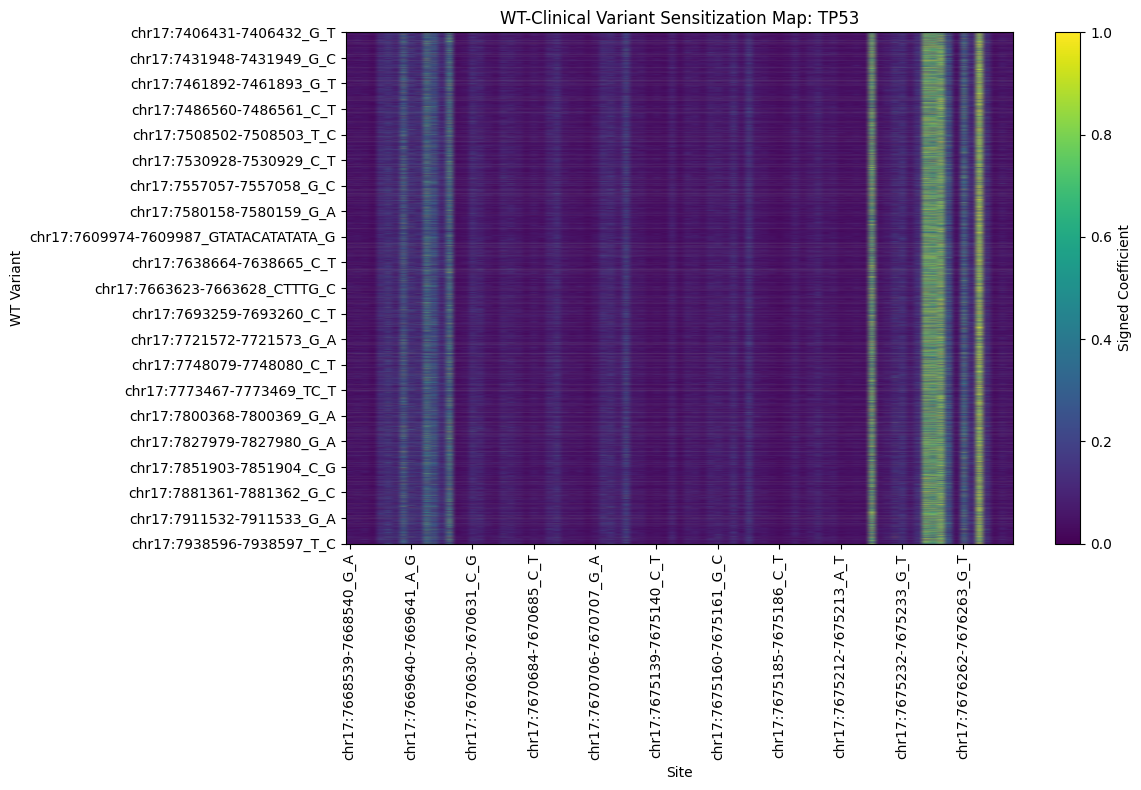

In [28]:
Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]

# Min-max normalize the columns of Xcoef
Xcoef = mc.minmax_normalize(Xcoef, procedure=["rows",])
# Xcoef = np.log10(Xcoef + 1e-6)

print(Xcoef.shape)

plt.figure(figsize=(12, 8))
im = plt.imshow(Xcoef.values, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Signed Coefficient")
plt.xlabel("Site")
plt.ylabel("WT Variant")
plt.title(f"WT-Clinical Variant Sensitization Map: {gene}")
plt.xticks(
    ticks=range(0, Xcoef.shape[1], max(1, Xcoef.shape[1] // 10)),
    labels=Xcoef.columns[::max(1, Xcoef.shape[1] // 10)],
    rotation=90
)
plt.yticks(
    ticks=range(0, Xcoef.shape[0], max(1, Xcoef.shape[0] // 20)),
    labels=Xcoef.index[::max(1, Xcoef.shape[0] // 20)]
)
plt.tight_layout()
plt.show()


Normalizing rows


Text(0.5, 0.98, 'WT-Clinical Variant Sensitization Map: TP53')

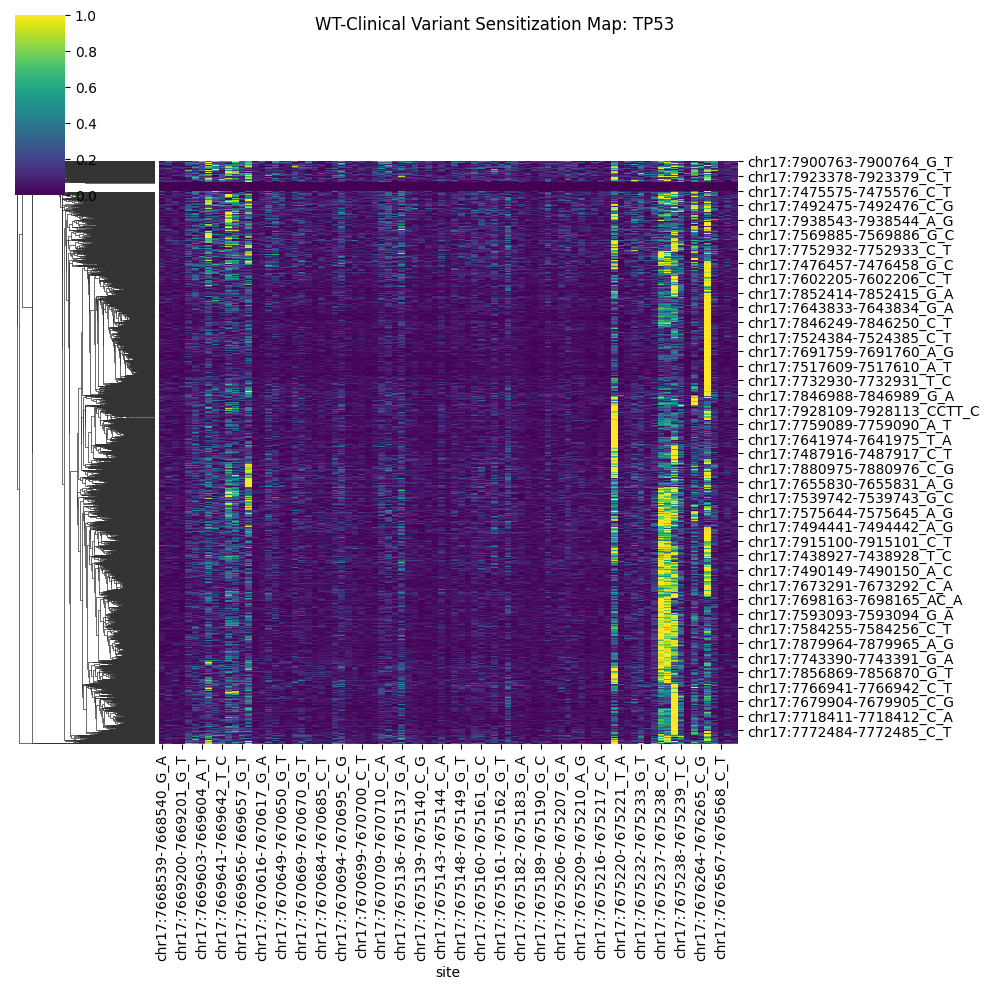

In [29]:
import seaborn as sns
Xcoef = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]

Xcoef = mc.minmax_normalize(Xcoef, procedure=["rows",])
Xcoef.fillna(0, inplace=True)


g = sns.clustermap(Xcoef, 
                    cmap='viridis', 
                    row_cluster=True,
                    col_cluster=False) 
g.fig.suptitle(f"WT-Clinical Variant Sensitization Map: {gene}")


Test whether there's a relationships between genomic position distance and interaction strength.

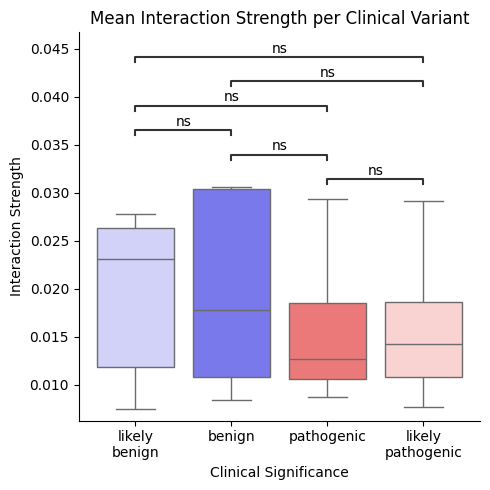

In [ ]:
clinsig_boxplot = ab.plot_clinsig_interaction_strength(
    ridge_df=ridge_df,  
    site_col="site",
    x="CLNSIG_simple",
)

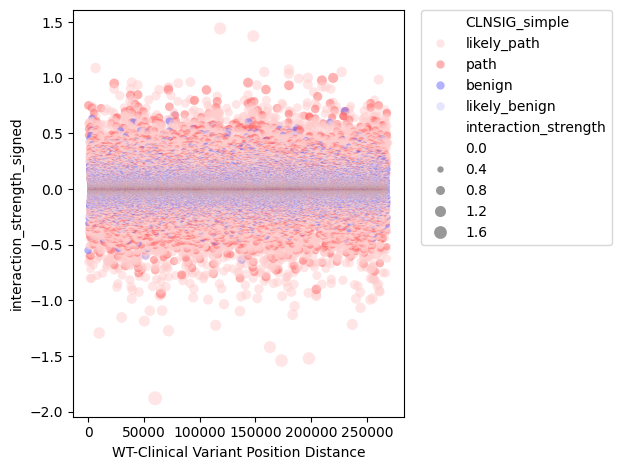

In [30]:
palette = utils.get_clinsig_palette()
# scatter_df utils.sort_by_clinsig(ridge_df.loc[~ridge_df["wt_variant"].str.endswith(">")])
ax = sns.scatterplot(
    x="position_distance", 
    y="interaction_strength_signed",
    size="interaction_strength",
    hue="CLNSIG_simple",
    palette=palette,
    sizes=(0.0001,100),
    alpha=0.5,
    data=ridge_df
)
plt.xlabel("WT-Clinical Variant Position Distance")
# Place the legend outside to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

Test whether there's a relationship between the LD and interaction strength.

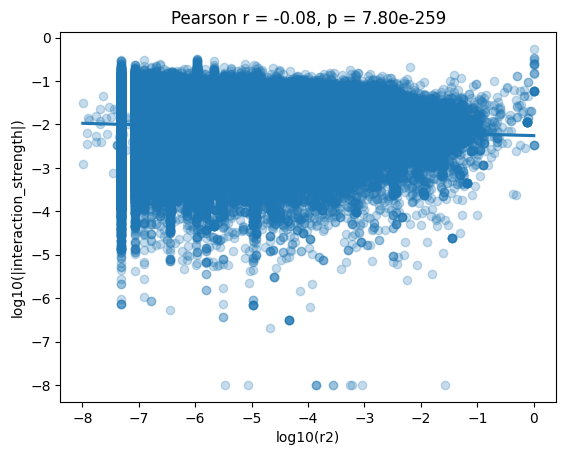

In [43]:
if 'Xld' not in globals():
    Xld = np.corrcoef(hap_matrix, rowvar=False) 

# Precompute mapping from wt_variant and clinical_position to Xld indices for speed
pos_to_idx = {int(str(name).split(":")[1].split("-")[0]): i for i, name in enumerate(Xwt.columns)}

def fast_get_r(row):
    x_idx = pos_to_idx.get(row["wt_position"], None)
    y_idx = pos_to_idx.get(row["clinical_position"], None)
    if x_idx is not None and y_idx is not None:
        return Xld[x_idx, y_idx]
    else:
        return np.nan

ridge_df["r"] = ridge_df.apply(fast_get_r, axis=1)
ridge_df["r2"] = ridge_df["r"]**2


from scipy.stats import pearsonr

# Compute log10 values
log_r2 = np.log10(ridge_df["r2"] + 1e-8)
log_interaction_strength = np.log10(ridge_df["interaction_strength"].abs() + 1e-8)

# Remove NaNs and infs for correlation and plotting
mask = (
    log_r2.notna() & log_interaction_strength.notna() &
    np.isfinite(log_r2) & np.isfinite(log_interaction_strength)
)
log_r2_clean = log_r2[mask]
log_interaction_strength_clean = log_interaction_strength[mask]

# Plot
sns.regplot(
    x=log_r2_clean, 
    y=log_interaction_strength_clean,
    scatter_kws={'alpha':0.25}
)
plt.xlabel("log10(r2)")
plt.ylabel("log10(|interaction_strength|)")

# Pearson correlation
if len(log_r2_clean) > 1:
    pearson_r, pearson_p = pearsonr(log_r2_clean, log_interaction_strength_clean)
    plt.title(f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}")
else:
    plt.title("Not enough data for Pearson correlation")

## Compare to ABC maps

In [386]:
abc = pd.read_csv("https://mitra.stanford.edu/engreitz/oak/public/Nasser2021/AllPredictions.AvgHiC.ABC0.015.minus150.ForABCPaperV3.txt.gz", 
                  sep="\t")
print(abc.shape)
abc.head()

(7717392, 24)


,chr,start,end,name,class,activity_base,TargetGene,TargetGeneTSS,TargetGeneExpression,TargetGenePromoterActivityQuantile,TargetGeneIsExpressed,distance,isSelfPromoter,hic_contact,powerlaw_contact,powerlaw_contact_reference,hic_contact_pl_scaled,hic_pseudocount,hic_contact_pl_scaled_adj,ABC.Score.Numerator,ABC.Score,powerlaw.Score.Numerator,powerlaw.Score,CellType
0,chr1,710010,710210,genic|chr1:709860-710360,genic,0.420794,LOC100288069,714068,NaN,0.815301,True,3958.0,False,0.125372,0.125372,0.123436,0.123436,0.001216,0.124652,0.052453,0.025955,0.051941,0.021762,brite_adipose-Loft2014
1,chr1,710036,710236,genic|chr1:709886-710386,genic,0.373477,LOC100288069,714068,NaN,0.843633,True,3932.0,False,0.125372,0.125372,0.123436,0.123436,0.001216,0.124652,0.046555,0.021446,0.046101,0.016866,white_adipose-Loft2014
2,chr1,710526,710956,genic|chr1:710376-711106,genic,0.776180,LOC100288069,714068,NaN,0.871313,True,3327.0,False,0.125372,0.125372,0.123436,0.123436,0.001216,0.124652,0.096752,0.032996,0.095809,0.026123,OCI-LY7-ENCODE
3,chr1,713731,714569,promoter|chr1:713581-714719,promoter,7.879375,LOC100288069,714068,NaN,0.699935,True,82.0,True,0.125372,0.125372,0.123436,0.123436,0.001216,0.124652,0.982179,0.539952,0.972599,0.370969,A673-ENCODE
4,chr1,713743,714641,promoter|chr1:713593-714791,promoter,12.744314,LOC100288069,714068,NaN,0.815301,True,124.0,True,0.125372,0.125372,0.123436,0.123436,0.001216,0.124652,1.588603,0.786091,1.573108,0.659092,brite_adipose-Loft2014


In [391]:
import src.pyliftover as pf

abc_chrom= pf.liftover(
    df=abc.loc[abc["chr"] == chrom],
    from_build='hg19',
    to_build='hg38',
    chrom_col='chr',
    position_cols=['start', 'end']
)

/home/schilder/projects/VEP_DNA/src/pyliftover.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_pos_col] = new_positions
/home/schilder/projects/VEP_DNA/src/pyliftover.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_pos_col] = new_positions


Only a single combination of anchors overlapped with ridge_df WT and clinical positions.

Conclusion: ABC isn't a useful strategy for validating sensitization maps.

In [412]:
import pyranges as pr
import pandas as pd

# 1. Treat ABC start and end as anchor centers, expand by +/-10bp, and create two anchor sets
abc_anchor1 = abc_chrom[["chr", "start_hg38"]].copy()
abc_anchor1 = abc_anchor1.rename(columns={"chr": "Chromosome", "start_hg38": "Position"})
abc_anchor1["Start"] = abc_anchor1["Position"] - 10
abc_anchor1["End"] = abc_anchor1["Position"] + 10
abc_anchor1["anchor_id"] = abc_chrom.index
abc_anchor1["anchor_type"] = "anchor1"

abc_anchor2 = abc_chrom[["chr", "end_hg38"]].copy()
abc_anchor2 = abc_anchor2.rename(columns={"chr": "Chromosome", "end_hg38": "Position"})
abc_anchor2["Start"] = abc_anchor2["Position"] - 10
abc_anchor2["End"] = abc_anchor2["Position"] + 10
abc_anchor2["anchor_id"] = abc_chrom.index
abc_anchor2["anchor_type"] = "anchor2"

# Combine anchors
abc_anchors = pd.concat([abc_anchor1, abc_anchor2], ignore_index=True)
abc_anchors_pr = pr.PyRanges(abc_anchors[["Chromosome", "Start", "End", "anchor_id", "anchor_type"]])

# 2. Prepare ridge_df as two sets of single-point PyRanges: one for wt_position, one for clinical_position
ridge_df["chr"] = ridge_df["site"].str.split(":").str[0]
ridge_wt = ridge_df[["chr", "wt_position"]].copy()
ridge_wt = ridge_wt.rename(columns={"chr": "Chromosome", "wt_position": "Position"})
ridge_wt["Start"] = ridge_wt["Position"]
ridge_wt["End"] = ridge_wt["Position"] + 1
ridge_wt["ridge_id"] = ridge_df.index
ridge_wt["var_type"] = "wt"

ridge_clin = ridge_df[["chr", "clinical_position"]].copy()
ridge_clin = ridge_clin.rename(columns={"chr": "Chromosome", "clinical_position": "Position"})
ridge_clin["Start"] = ridge_clin["Position"]
ridge_clin["End"] = ridge_clin["Position"] + 1
ridge_clin["ridge_id"] = ridge_df.index
ridge_clin["var_type"] = "clinical"

ridge_vars = pd.concat([ridge_wt, ridge_clin], ignore_index=True)
ridge_vars_pr = pr.PyRanges(ridge_vars[["Chromosome", "Start", "End", "ridge_id", "var_type"]])

# 3. Find overlaps between ridge variants and anchors
overlaps = ridge_vars_pr.join(abc_anchors_pr, suffix="_anchor")

# 4. For each ridge_id, find cases where both positions (wt and clinical) overlap the two different anchors of the same ABC pair
#    (i.e., one in anchor1, one in anchor2, and both with the same anchor_id)
overlap_df = overlaps.df

# Pivot so we can check for both anchor types per ridge_id and anchor_id
# Use "Start" as the position value, since "Position" is not present in overlap_df
pivot = overlap_df.pivot_table(
    index=["ridge_id", "anchor_id"],
    columns=["var_type", "anchor_type"],
    values="Start",
    aggfunc="first"
)

# Find cases where one variant is in anchor1 and the other in anchor2 (regardless of which is which)
def anchor_pair_match(row):
    wt_in_1 = not pd.isna(row.get(("wt", "anchor1")))
    wt_in_2 = not pd.isna(row.get(("wt", "anchor2")))
    clin_in_1 = not pd.isna(row.get(("clinical", "anchor1")))
    clin_in_2 = not pd.isna(row.get(("clinical", "anchor2")))
    # One in anchor1, one in anchor2, and not both in the same anchor
    return (wt_in_1 and clin_in_2) or (wt_in_2 and clin_in_1)

# The output of pivot has MultiIndex columns, but ridge_df and abc_chrom are flat.
# To avoid MergeError, flatten the columns before merging.
matches = pivot[pivot.apply(anchor_pair_match, axis=1)].reset_index()
# Flatten columns for matches so that merges work (remove column MultiIndex)
matches.columns = [
    "_".join([str(l) for l in col if l]) if isinstance(col, tuple) else str(col)
    for col in matches.columns
]

# Merge back to get full ridge_df and abc_chrom info
if not matches.empty:
    # Get original ridge and abc rows
    matches = matches.merge(ridge_df.reset_index().rename(columns={"index": "ridge_id"}), on="ridge_id", how="left")
    matches = matches.merge(abc_chrom.reset_index().rename(columns={"index": "anchor_id"}), on="anchor_id", how="left")
overlap_df = matches

overlap_df.head()


,ridge_id,anchor_id,clinical_anchor1,clinical_anchor2,wt_anchor1,wt_anchor2,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,r,r2,chr_x,chr_y,start,end,name,class,activity_base,TargetGene,TargetGeneTSS,TargetGeneExpression,TargetGenePromoterActivityQuantile,TargetGeneIsExpressed,distance,isSelfPromoter,hic_contact,powerlaw_contact,powerlaw_contact_reference,hic_contact_pl_scaled,hic_pseudocount,hic_contact_pl_scaled_adj,ABC.Score.Numerator,ABC.Score,powerlaw.Score.Numerator,powerlaw.Score,CellType,start_hg38,end_hg38
0,1164461,7206291,NaN,35049170.0,35047124.0,NaN,35047124>,chr21:35049170-35049171_C_T,0.009296,-0.009296,more pathogenic,3,0.166997,chr21:35049170-35049171_C_T,35047124,35049170,2046,NaN,NaN,chr21,chr21,36419429,36421474,intergenic|chr21:36419279-36421624,intergenic,37.604599,MRPS6,35445822,NaN,0.544097,True,974629.5,False,0.000391,0.001243,0.001257,0.000395,0.001216,0.001611,0.060586,0.022489,0.047268,0.014159,THP_pmaLPS_ATAC_72h,35047132,35049177
1,1164461,7206292,NaN,35049170.0,35047124.0,NaN,35047124>,chr21:35049170-35049171_C_T,0.009296,-0.009296,more pathogenic,3,0.166997,chr21:35049170-35049171_C_T,35047124,35049170,2046,NaN,NaN,chr21,chr21,36419429,36421474,intergenic|chr21:36419279-36421624,intergenic,37.604599,LOC100133286,37498938,NaN,0.438854,True,1078486.5,False,0.000478,0.001138,0.001151,0.000483,0.001138,0.001622,0.060977,0.023751,0.043283,0.010960,THP_pmaLPS_ATAC_72h,35047132,35049177
2,1164461,7206293,NaN,35049170.0,35047124.0,NaN,35047124>,chr21:35049170-35049171_C_T,0.009296,-0.009296,more pathogenic,3,0.166997,chr21:35049170-35049171_C_T,35047124,35049170,2046,NaN,NaN,chr21,chr21,36419429,36421474,intergenic|chr21:36419279-36421624,intergenic,37.604599,SLC5A3,35445822,NaN,0.544097,True,974629.5,False,0.000391,0.001243,0.001257,0.000395,0.001216,0.001611,0.060586,0.022489,0.047268,0.014159,THP_pmaLPS_ATAC_72h,35047132,35049177
3,1164461,7206294,NaN,35049170.0,35047124.0,NaN,35047124>,chr21:35049170-35049171_C_T,0.009296,-0.009296,more pathogenic,3,0.166997,chr21:35049170-35049171_C_T,35047124,35049170,2046,NaN,NaN,chr21,chr21,36419429,36421474,intergenic|chr21:36419279-36421624,intergenic,37.604599,SMIM11A,35747748,NaN,0.777416,True,672703.5,False,0.000737,0.001720,0.001735,0.000743,0.001216,0.001959,0.073666,0.026353,0.065261,0.017593,THP_pmaLPS_ATAC_72h,35047132,35049177
4,1164461,7206295,NaN,35049170.0,35047124.0,NaN,35047124>,chr21:35049170-35049171_C_T,0.009296,-0.009296,more pathogenic,3,0.166997,chr21:35049170-35049171_C_T,35047124,35049170,2046,NaN,NaN,chr21,chr21,36419429,36421474,intergenic|chr21:36419279-36421624,intergenic,37.604599,SMIM11B,35747778,NaN,0.776357,True,672673.5,False,0.000737,0.001720,0.001736,0.000743,0.001216,0.001959,0.073666,0.026353,0.065264,0.017594,THP_pmaLPS_ATAC_72h,35047132,35049177
